# 02 — Gradient descent in depth

Chapter 01 used the simplest possible version. Every serious training loop since
2015 uses a variant of it. This chapter builds up from batch gradient descent to
Adam, and shows *why* each modification exists.

The questions we answer:

- What does the gradient actually point at, and why walk against it?
- Batch, stochastic, or mini-batch — what is the real trade-off?
- What problem does momentum solve that a bigger learning rate cannot?
- Why did adaptive methods take over?

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
rng = np.random.default_rng(42)

## What a gradient is

The gradient of $f$ at a point is the vector of partial derivatives. It points in
the direction of **steepest increase**. So $-\nabla f$ points downhill, and

$$\theta \leftarrow \theta - \eta \nabla f(\theta)$$

is the entire algorithm. Everything else in this chapter is a refinement of that
one line.

Let's watch it on a surface we can draw.

In [2]:
def f(theta):
    """An elongated bowl. The 10x asymmetry is what makes it interesting."""
    return theta[0] ** 2 + 10 * theta[1] ** 2

def grad_f(theta):
    return np.array([2 * theta[0], 20 * theta[1]])

def descend(grad_fn, start, lr, n_steps, update=None):
    """Run gradient descent, recording every point visited."""
    theta = np.array(start, dtype=float)
    path = [theta.copy()]
    state = {}
    for t in range(1, n_steps + 1):
        g = grad_fn(theta)
        if update is None:
            theta = theta - lr * g
        else:
            theta, state = update(theta, g, lr, state, t)
        path.append(theta.copy())
    return np.array(path)

path = descend(grad_f, start=[-4.0, 2.0], lr=0.05, n_steps=40)
print("start:", path[0], " end:", path[-1].round(4))

start: [-4.  2.]  end: [-0.059  0.   ]


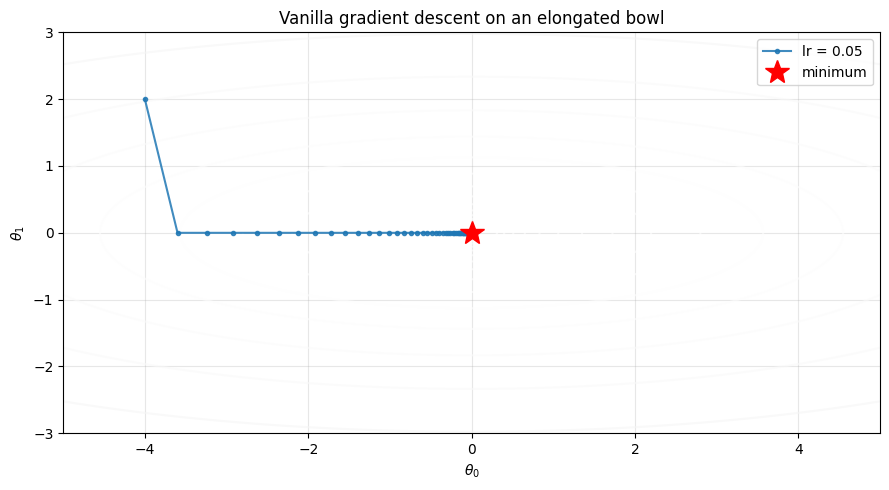

In [3]:
def plot_paths(paths_dict, title):
    xs = np.linspace(-5, 5, 200)
    ys = np.linspace(-3, 3, 200)
    XX, YY = np.meshgrid(xs, ys)
    ZZ = XX ** 2 + 10 * YY ** 2

    plt.figure(figsize=(9, 5))
    plt.contour(XX, YY, ZZ, levels=np.logspace(-1, 3, 20), cmap="Greys", alpha=0.6)
    for label, p in paths_dict.items():
        plt.plot(p[:, 0], p[:, 1], "o-", ms=3, lw=1.5, label=label, alpha=0.85)
    plt.plot(0, 0, "r*", ms=18, label="minimum")
    plt.xlabel(r"$\theta_0$"); plt.ylabel(r"$\theta_1$")
    plt.title(title); plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

plot_paths({"lr = 0.05": path}, "Vanilla gradient descent on an elongated bowl")

Notice the zig-zag. The surface is 10x steeper along $\theta_1$ than $\theta_0$,
so the gradient is dominated by the steep direction and the path oscillates
across the valley instead of running along it.

Raising the learning rate makes this worse, not better — the oscillation diverges
before the flat direction makes progress.

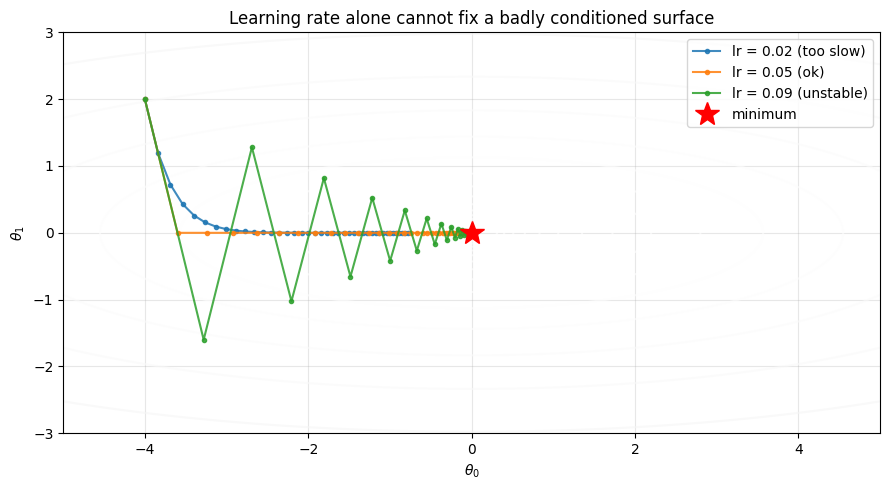

In [4]:
plot_paths({
    "lr = 0.02 (too slow)": descend(grad_f, [-4.0, 2.0], 0.02, 40),
    "lr = 0.05 (ok)":       descend(grad_f, [-4.0, 2.0], 0.05, 40),
    "lr = 0.09 (unstable)": descend(grad_f, [-4.0, 2.0], 0.09, 40),
}, "Learning rate alone cannot fix a badly conditioned surface")

## Momentum

Accumulate a velocity vector instead of stepping on the raw gradient:

$$v \leftarrow \beta v - \eta \nabla f(\theta), \qquad \theta \leftarrow \theta + v$$

Consistent directions reinforce across steps; oscillating directions cancel out.
That is exactly the asymmetry we need on this surface — the flat direction gets
faster, the zig-zag gets damped.

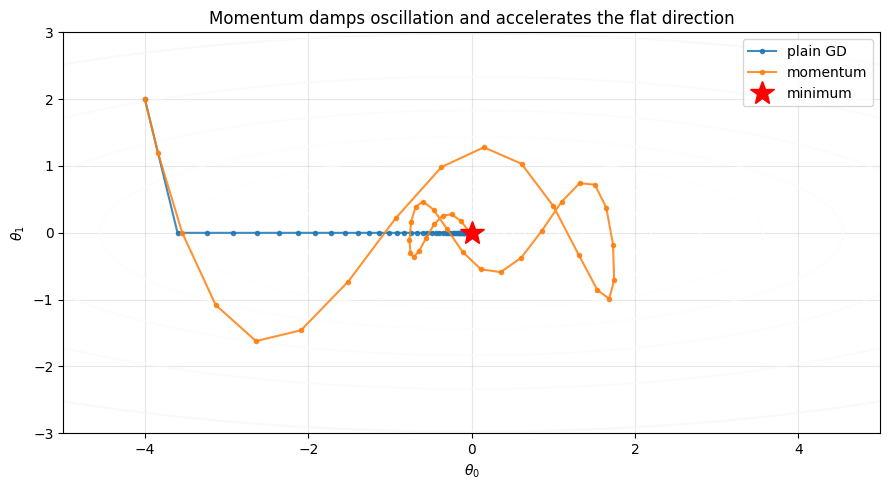

In [5]:
def momentum_update(theta, g, lr, state, t, beta=0.9):
    v = state.get("v", np.zeros_like(theta))
    v = beta * v - lr * g
    state["v"] = v
    return theta + v, state

plot_paths({
    "plain GD": descend(grad_f, [-4.0, 2.0], 0.05, 40),
    "momentum": descend(grad_f, [-4.0, 2.0], 0.02, 40, update=momentum_update),
}, "Momentum damps oscillation and accelerates the flat direction")

## Adam

Momentum uses one learning rate for every parameter. Adam gives each parameter
its own, scaled by a running estimate of its gradient magnitude:

$$m \leftarrow \beta_1 m + (1-\beta_1) g \qquad \text{(first moment)}$$
$$v \leftarrow \beta_2 v + (1-\beta_2) g^2 \qquad \text{(second moment)}$$
$$\theta \leftarrow \theta - \eta \frac{\hat{m}}{\sqrt{\hat{v}} + \epsilon}$$

Parameters with consistently large gradients get divided by a large $\sqrt{v}$
and take smaller steps. Parameters with tiny gradients take relatively larger
ones. The badly-conditioned surface effectively gets rescaled.

**Bias correction.** $m$ and $v$ start at zero, which drags the early estimates
toward zero. Dividing by $1 - \beta^t$ undoes that; the correction fades as $t$ grows.

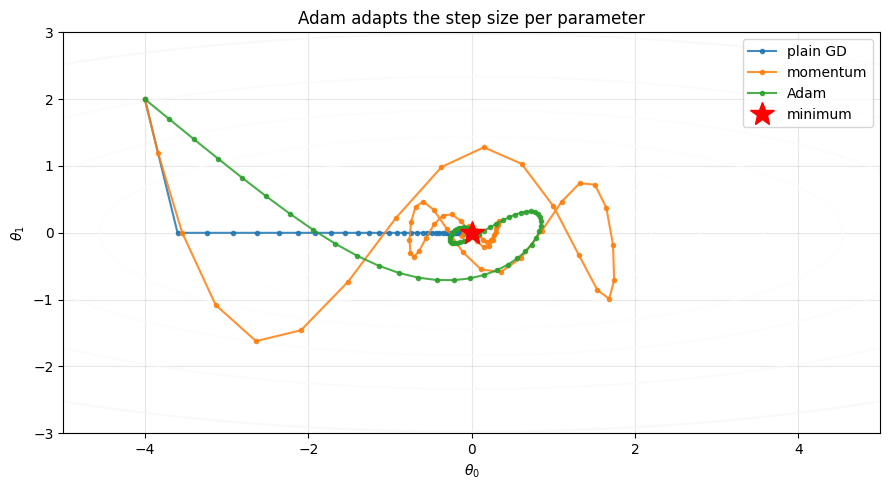

In [6]:
def adam_update(theta, g, lr, state, t, b1=0.9, b2=0.999, eps=1e-8):
    m = state.get("m", np.zeros_like(theta))
    v = state.get("v", np.zeros_like(theta))

    m = b1 * m + (1 - b1) * g
    v = b2 * v + (1 - b2) * g ** 2
    state["m"], state["v"] = m, v

    m_hat = m / (1 - b1 ** t)      # bias correction
    v_hat = v / (1 - b2 ** t)

    return theta - lr * m_hat / (np.sqrt(v_hat) + eps), state

plot_paths({
    "plain GD": descend(grad_f, [-4.0, 2.0], 0.05, 60),
    "momentum": descend(grad_f, [-4.0, 2.0], 0.02, 60, update=momentum_update),
    "Adam":     descend(grad_f, [-4.0, 2.0], 0.30, 60, update=adam_update),
}, "Adam adapts the step size per parameter")

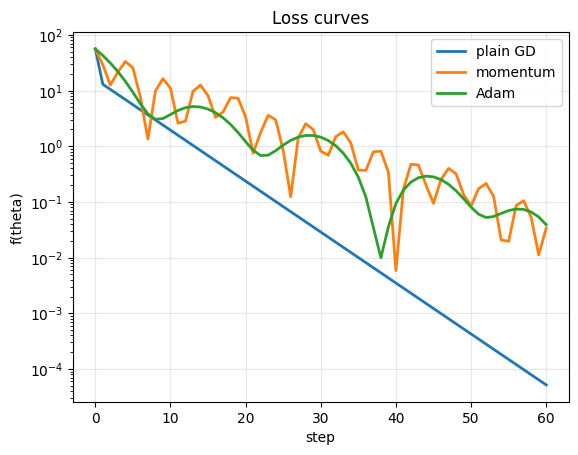

In [7]:
for name, path in [("plain GD", descend(grad_f, [-4.0, 2.0], 0.05, 60)),
                   ("momentum", descend(grad_f, [-4.0, 2.0], 0.02, 60, update=momentum_update)),
                   ("Adam",     descend(grad_f, [-4.0, 2.0], 0.30, 60, update=adam_update))]:
    losses = [f(p) for p in path]
    plt.plot(losses, lw=2, label=name)

plt.yscale("log"); plt.xlabel("step"); plt.ylabel("f(theta)")
plt.title("Loss curves"); plt.legend(); plt.grid(alpha=0.3); plt.show()

## Batch vs stochastic vs mini-batch

| Variant | Samples per update | Gradient quality | Updates per epoch |
|---|---|---|---|
| Batch | all `n` | exact | 1 |
| Stochastic | 1 | very noisy | `n` |
| Mini-batch | 32–256 | good enough | `n / batch_size` |

Mini-batch wins in practice for two reasons: the noise averages out enough to
point roughly downhill, and a batch of 128 is one matrix multiply — the same
hardware cost as a batch of 1 on modern hardware.

The noise is not purely a cost, either. It helps escape sharp minima.

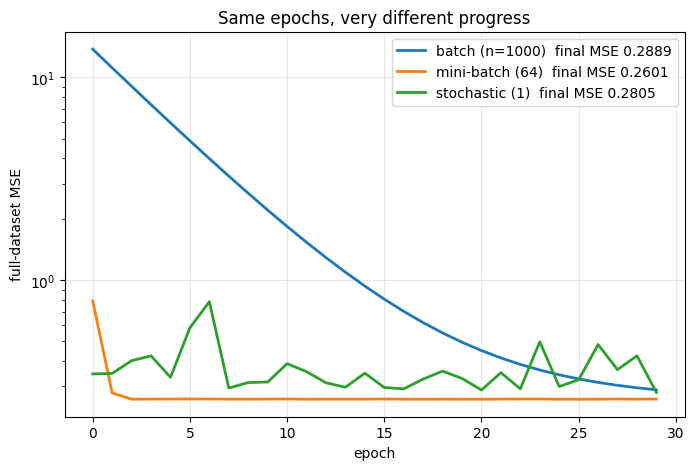

In [8]:
from mlscratch.utils import iterate_minibatches

X = rng.normal(size=(1000, 5))
true_w = np.array([1.0, -2.0, 0.5, 3.0, -1.5])
y = X @ true_w + rng.normal(0, 0.5, 1000)

def train(batch_size, epochs=30, lr=0.05):
    w = np.zeros(5)
    losses = []
    for ep in range(epochs):
        for xb, yb in iterate_minibatches(X, y, batch_size, seed=ep):
            g = (2.0 / len(xb)) * xb.T @ (xb @ w - yb)
            w = w - lr * g
        losses.append(np.mean((X @ w - y) ** 2))
    return w, losses

plt.figure(figsize=(8, 5))
for bs, label in [(1000, "batch (n=1000)"), (64, "mini-batch (64)"), (1, "stochastic (1)")]:
    w, losses = train(bs)
    plt.plot(losses, lw=2, label=f"{label}  final MSE {losses[-1]:.4f}")

plt.xlabel("epoch"); plt.ylabel("full-dataset MSE"); plt.yscale("log")
plt.title("Same epochs, very different progress"); plt.legend(); plt.grid(alpha=0.3); plt.show()

Batch gradient descent gets one update per epoch — 30 updates total. Mini-batch
gets ~16 per epoch. Same number of passes over the data, far more progress.

## Exercises

1. **Nesterov momentum.** Evaluate the gradient at $\theta + \beta v$ instead of
   $\theta$. Implement it and compare the path.
2. **Learning rate schedules.** Add exponential decay $\eta_t = \eta_0 e^{-kt}$.
   Where does it help, and where does it just slow you down?
3. **RMSProp.** Adam without the first moment. Implement it and isolate what
   momentum contributes.
4. **Condition number.** Change `10 * theta[1]**2` to `100 * theta[1]**2`.
   Which optimiser degrades most?

---

**Next:** [03 — Logistic regression and classification](03_logistic_regression.ipynb)